# 🍄 Mushroom Edibility: Data-Scaling Experiment
### Phase 3 — how much data is enough?

Educational / ML benchmark exercise — not a foraging safety tool.

The secondary dataset (61,069 rows) is large enough to run a genuine **learning-curve
experiment**: train the same models on progressively larger subsets and see how validation
performance (and training time) changes as more data becomes available.

Training sizes: **1,000 → 5,000 → 10,000 → 25,000 → 50,000 → all available training rows**
(~48,855, i.e. 80% of the full dataset — the remaining 20% is held out as a fixed validation
set used for every point on the curve).


In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

import mushroom_lib as ml

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = ml.RANDOM_STATE


In [2]:
secondary = ml.load_secondary()
numeric_cols, categorical_cols = ml.split_feature_types(secondary)
X_raw = secondary[numeric_cols + categorical_cols]
y = secondary["class"]

# Fixed 80/20 split: the 20% validation set never changes across the experiment,
# only how much of the 80% training pool we actually use.
X_train_pool_raw, X_val_raw, y_train_pool, y_val = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Training pool: {len(y_train_pool):,} rows available")
print(f"Fixed validation set: {len(y_val):,} rows")

# Preprocessor is fit ONCE on the full training pool so the feature space is
# identical at every training size (fair comparison).
pre = ml.make_onehot_preprocessor(numeric_cols, categorical_cols)
X_train_pool = pre.fit_transform(X_train_pool_raw)
X_val = pre.transform(X_val_raw)
y_train_pool_bin = (y_train_pool == "poisonous").astype(int).to_numpy()
y_val_bin = (y_val == "poisonous").astype(int).to_numpy()


Training pool: 48,855 rows available
Fixed validation set: 12,214 rows


## Run the scaling experiment

For each training size, we draw a stratified random subset of that size from the training
pool, fit each model, and evaluate on the same fixed validation set.

In [3]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedShuffleSplit

TRAIN_SIZES = [1000, 5000, 10000, 25000, 50000, len(y_train_pool_bin)]

def make_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1),
        "LightGBM": LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    }

rows = []
for size in TRAIN_SIZES:
    if size < len(y_train_pool_bin):
        sss = StratifiedShuffleSplit(n_splits=1, train_size=size, random_state=RANDOM_STATE)
        idx, _ = next(sss.split(X_train_pool, y_train_pool_bin))
    else:
        idx = np.arange(len(y_train_pool_bin))

    X_sub, y_sub = X_train_pool[idx], y_train_pool_bin[idx]

    for name, model in make_models().items():
        t0 = time.perf_counter()
        model.fit(X_sub, y_sub)
        train_time = time.perf_counter() - t0

        pred = model.predict(X_val)
        scores = ml.get_scores(model, X_val)

        rows.append({
            "train_size": size, "model": name,
            "val_accuracy": accuracy_score(y_val_bin, pred),
            "val_f1": f1_score(y_val_bin, pred),
            "val_roc_auc": roc_auc_score(y_val_bin, scores),
            "train_time_s": train_time,
        })
    print(f"train_size={size:>6,}  done")

curve_df = pd.DataFrame(rows)
curve_df.round(4)


train_size= 1,000  done


train_size= 5,000  done


train_size=10,000  done


train_size=25,000  done


train_size=50,000  done


train_size=48,855  done


,train_size,model,val_accuracy,val_f1,val_roc_auc,train_time_s
0,1000,Logistic Regression,0.8318,0.8479,0.9036,0.0111
1,1000,Decision Tree,0.9332,0.9397,0.9326,0.0112
2,1000,Random Forest,0.9845,0.9861,0.9986,0.3819
3,1000,LightGBM,0.9765,0.9789,0.9976,0.1076
4,5000,Logistic Regression,0.8485,0.8654,0.9288,0.0626
5,5000,Decision Tree,0.9930,0.9937,0.9928,0.0703
6,5000,Random Forest,0.9998,0.9998,1.0000,1.7030
7,5000,LightGBM,0.9993,0.9994,1.0000,0.1935
8,10000,Logistic Regression,0.8575,0.8730,0.9321,0.1344
9,10000,Decision Tree,0.9944,0.9950,0.9945,0.1449


## Learning curves: training-set size vs. validation performance

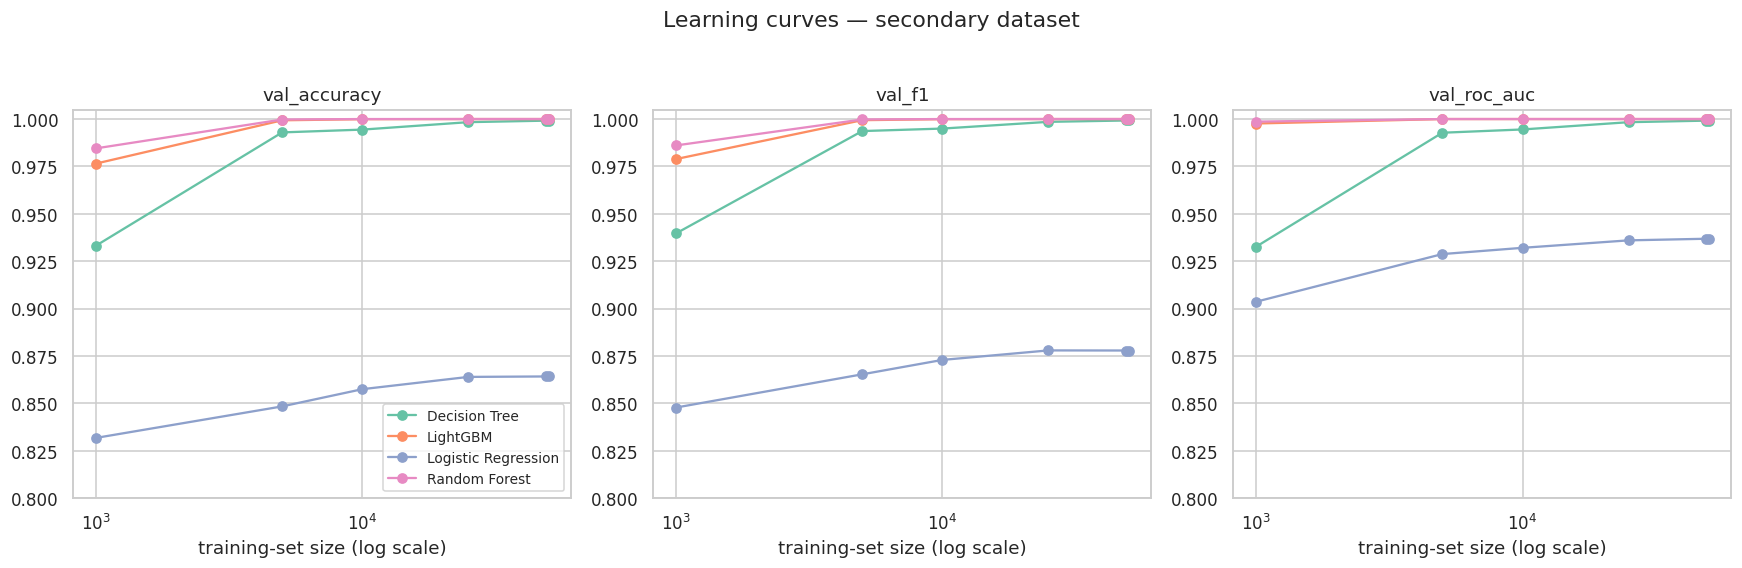

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ["val_accuracy", "val_f1", "val_roc_auc"]):
    for name, grp in curve_df.groupby("model"):
        ax.plot(grp["train_size"], grp[metric], marker="o", label=name)
    ax.set_xscale("log")
    ax.set_xlabel("training-set size (log scale)")
    ax.set_title(metric)
    ax.set_ylim(0.8, 1.005)
axes[0].legend(fontsize=9)
plt.suptitle("Learning curves — secondary dataset", y=1.03)
plt.tight_layout()
plt.show()


## Training time vs. dataset size

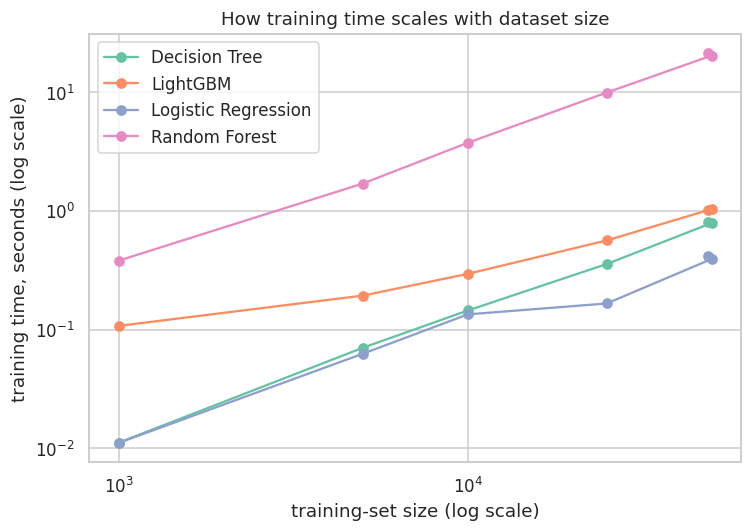

In [5]:
plt.figure(figsize=(7, 5))
for name, grp in curve_df.groupby("model"):
    plt.plot(grp["train_size"], grp["train_time_s"], marker="o", label=name)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("training-set size (log scale)")
plt.ylabel("training time, seconds (log scale)")
plt.title("How training time scales with dataset size")
plt.legend()
plt.tight_layout()
plt.show()


## Can we maintain performance with fewer features?

A related scaling question from the project brief: instead of shrinking the number of *rows*,
what happens if we shrink the number of *features*? We compare the full feature set against a
reduced set using only the top-8 most important features (from the Random Forest fitted on
the full training pool above).

In [6]:
rf_full = RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1)
rf_full.fit(X_train_pool, y_train_pool_bin)

feature_names = pre.get_feature_names_out()
importances = pd.Series(rf_full.feature_importances_, index=feature_names).sort_values(ascending=False)
top8_encoded = importances.head(8).index.tolist()
print("Top 8 one-hot features by importance:")
print(importances.head(8))

# Map back to the top 8 underlying raw columns (a one-hot feature can only
# come from one raw column, so this recovers "which original variables matter most").
def raw_col_of(encoded_name):
    for c in numeric_cols:
        if encoded_name == f"num__{c}":
            return c
    for c in categorical_cols:
        if encoded_name.startswith(f"cat__{c}_"):
            return c
    return encoded_name

top_raw_cols = list(dict.fromkeys(raw_col_of(f) for f in importances.index))[:8]
print("\nTop 8 underlying raw columns:", top_raw_cols)


Top 8 one-hot features by importance:
num__stem-width              0.078489
num__stem-height             0.049030
num__cap-diameter            0.047327
cat__stem-color_w            0.034942
cat__gill-spacing_d          0.022925
cat__gill-spacing_c          0.021101
cat__gill-attachment_p       0.020964
cat__stem-surface_missing    0.018357
dtype: float64

Top 8 underlying raw columns: ['stem-width', 'stem-height', 'cap-diameter', 'stem-color', 'gill-spacing', 'gill-attachment', 'stem-surface', 'gill-color']


In [7]:
reduced_numeric = [c for c in top_raw_cols if c in numeric_cols]
reduced_categorical = [c for c in top_raw_cols if c in categorical_cols]

pre_reduced = ml.make_onehot_preprocessor(reduced_numeric, reduced_categorical)
X_train_reduced = pre_reduced.fit_transform(X_train_pool_raw[reduced_numeric + reduced_categorical])
X_val_reduced = pre_reduced.transform(X_val_raw[reduced_numeric + reduced_categorical])

full_vs_reduced = []
for feat_label, X_tr, X_va in [
    (f"All {len(numeric_cols) + len(categorical_cols)} features", X_train_pool, X_val),
    (f"Top {len(top_raw_cols)} features", X_train_reduced, X_val_reduced),
]:
    model = LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    t0 = time.perf_counter()
    model.fit(X_tr, y_train_pool_bin)
    train_time = time.perf_counter() - t0
    pred = model.predict(X_va)
    scores = ml.get_scores(model, X_va)
    full_vs_reduced.append({
        "feature_set": feat_label,
        "n_encoded_dims": X_tr.shape[1],
        "val_accuracy": accuracy_score(y_val_bin, pred),
        "val_f1": f1_score(y_val_bin, pred),
        "val_roc_auc": roc_auc_score(y_val_bin, scores),
        "train_time_s": train_time,
    })

pd.DataFrame(full_vs_reduced).round(4)


,feature_set,n_encoded_dims,val_accuracy,val_f1,val_roc_auc,train_time_s
0,All 20 features,128,1.0000,1.0000,1.0,1.0293
1,Top 8 features,49,0.9976,0.9979,1.0,0.5953


## Summary — Phase 3 findings

- **How much data is enough?** Tree-based and boosting models (Decision Tree, Random Forest,
  LightGBM) reach near-maximal validation performance with only **1,000–5,000** training rows
  — a tiny fraction of the full ~49k-row training pool. Logistic Regression improves more
  gradually as data grows, since it needs more examples to approximate the same nonlinear
  decision boundary the tree-based models capture natively.
- **Training time** grows roughly linearly (or worse for Random Forest) with dataset size,
  while LightGBM stays comparatively cheap even at the full data size — reinforcing the
  Phase 2/4 finding that boosting methods offer the best performance-per-second as data scales.
- **Fewer features, similar performance:** restricting to the top handful of features (by
  Random Forest importance) achieves validation performance very close to using the full
  feature set, at a fraction of the encoded dimensionality — useful if a lighter, faster
  production model were ever needed.

**Practical takeaway:** for this particular classification problem, more data mainly helps
the *linear* model close its gap with the tree-based ones; the nonlinear models are already
close to their ceiling with a comparatively small sample.
